In [1]:
import os

os.environ['MPLCONFIGDIR'] = "/mnt/storage6/grace/plt_temp/" # setting config environment to writable directory to stop error message

import numpy as np
import xarray as xr
import glob
import time

import matplotlib as mpl
import matplotlib.pyplot as plt
import cartopy.crs as ccrs

path4 = "/mnt/storage6/myers/NEMO/ANHA4-EPM151/"
path12 = "/mnt/storage6/myers/NEMO/ANHA12-EXH006/"

Figure for ANHA4

In [2]:
bathy4 = xr.open_mfdataset(path4 + 'ANHA4_bathy_etopo1_gebco1.nc')
mask_land4 = np.ma.make_mask(bathy4['Bathymetry'] != 0)
bathy_levels = np.array([0, 100, 300, 1000, 3000, 5000])
bathy4.close()

#bathy12 = xr.open_mfdataset(path12 + 'ANHA12_bathy_etopo1_gebco1.nc')
#mask_land12 = np.ma.make_mask(bathy12['Bathymetry'] != 0)
#bathy_levels = np.array([0, 100, 300, 1000, 3000, 5000])
#bathy12.close()

ds_t4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridT.nc")
ds_i4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_icemod.nc")
ds_u4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridU.nc")
ds_v4 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA4-EPM151/ANHA4-EPM151_y2019m05d25_gridV.nc")

ds_t12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d30_gridT.nc")
ds_i12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d30_icemod.nc")
ds_u12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d30_gridU.nc")
ds_v12 = xr.open_mfdataset("/mnt/storage6/myers/NEMO/ANHA12-EXH006/ANHA12-EXH006_y2019m05d30_gridV.nc")

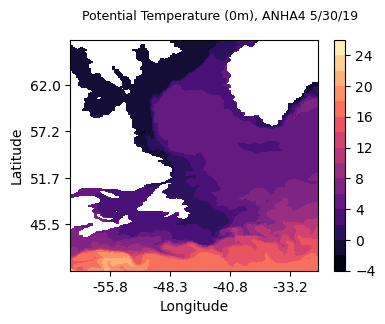

In [4]:
fig, ax = plt.subplots(figsize=(4, 3))
t4 = ds_t4['votemper'][0, 0, :,:]
t4 = np.where(mask_land4 > 0, t4, np.nan)

lab1 = ax.contourf(t4[250:450, 125:250], np.arange(-4,28,2), cmap='magma')

ax.set_yticks(np.array([40, 80, 120, 160]), np.trunc(10*ds_t4.nav_lat_grid_T.values[[290, 330, 370, 410], 150])/10)
ax.set_xticks(np.array([20, 50, 80, 110]), np.trunc(10* ds_t4.nav_lon_grid_T.values[250, [170, 200, 230, 260]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.suptitle("Potential Temperature (0m), ANHA4 5/30/19", fontsize=9)

fig.colorbar(lab1)

Text(0.5, 0.98, 'Practical Salinity (0m), ANHA4, 5/30/19')

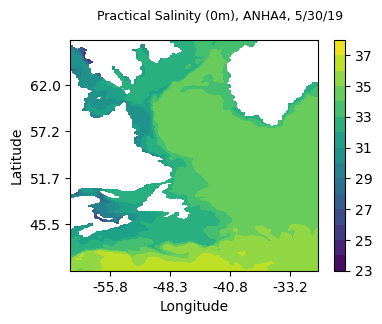

In [5]:
fig, ax = plt.subplots(figsize=(4, 3))
s4 = ds_t4['vosaline'][0, 0, :,:]
s4 = np.where(mask_land4 > 0, s4, np.nan)

lab2 = ax.contourf(s4[250:450, 125:250], np.arange(23,39,1), cmap='viridis')

#plt.plot([55+125, 85+125], [85, 85]) # x + 125 and y + 250 to get to model coords

ax.set_yticks(np.array([40, 80, 120, 160]), np.trunc(10*ds_t4.nav_lat_grid_T.values[[290, 330, 370, 410], 150])/10)
ax.set_xticks(np.array([20, 50, 80, 110]), np.trunc(10* ds_t4.nav_lon_grid_T.values[250, [170, 200, 230, 260]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(lab2)
fig.suptitle("Practical Salinity (0m), ANHA4, 5/30/19", fontsize=9)

Text(0.5, 0.98, 'Top 50m Average Velocity (m/s), ANHA4, 5/30/19')

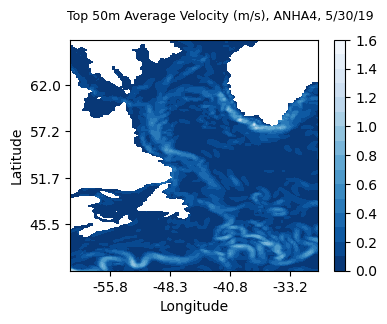

In [6]:
fig, ax = plt.subplots(figsize=(4, 3))

u4 = ds_u4['vozocrtx'][0, :19, 250:450, 125:250].mean('depthu').compute()
u4 = np.where(mask_land4[250:450, 125:250] > 0, u4, np.nan)

v4 = ds_v4['vomecrty'][0, :19, 250:450, 125:250].mean('depthv').compute()
v4 = np.where(mask_land4[250:450, 125:250] > 0, v4, np.nan)

lab3 = ax.contourf(np.sqrt(u4**2 + v4**2), np.arange(0, 1.7, .1), cmap='Blues_r')
#ax.quiver(ds_T4.nav_lat_grid_T[250:450, 125:250], ds_T4.nav_lon_grid_T[250:450, 125:250], u4[::2, ::2], v4[::2, ::2])

#plt.plot([55, 85], [85, 85], label = 'pre_GB')# x + 125 and y + 225 to get to model coords

ax.set_yticks(np.array([40, 80, 120, 160]), np.trunc(10*ds_t4.nav_lat_grid_T.values[[290, 330, 370, 410], 150])/10)
ax.set_xticks(np.array([20, 50, 80, 110]), np.trunc(10* ds_t4.nav_lon_grid_T.values[250, [170, 200, 230, 260]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(lab3)
fig.suptitle("Top 50m Average Velocity (m/s), ANHA4, 5/30/19", fontsize=9)


Text(0.5, 0.98, 'Ice Concentration (%), ANHA4, 5/30/19')

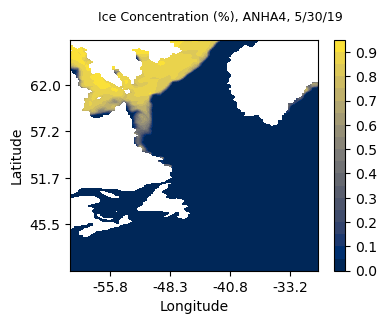

In [7]:
ic4 = ds_i4['ileadfra'][0, :,:]
ic4 = np.where(mask_land4 > 0, ic4, np.nan)

fig, ax = plt.subplots(figsize=(4, 3))

#plt.contour(bathy4['Bathymetry'][250:450,125:250], np.array([0, 100, 300, 1000, 3000, 5000]), colors = ['k']*len(bathy_levels), alpha = [1] + [.3]*(len(bathy_levels) -1), linewidths = .75)
lab4 = ax.contourf(ic4[250:450, 125:250], np.arange(0,1,.05), cmap='cividis')

ax.set_yticks(np.array([40, 80, 120, 160]), np.trunc(10*ds_t4.nav_lat_grid_T.values[[290, 330, 370, 410], 150])/10)
ax.set_xticks(np.array([20, 50, 80, 110]), np.trunc(10* ds_t4.nav_lon_grid_T.values[250, [170, 200, 230, 260]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(lab4)
fig.suptitle("Ice Concentration (%), ANHA4, 5/30/19", fontsize=9)

Text(0.5, 0.98, 'Ice Thickness (m), ANHA4, 5/30/19')

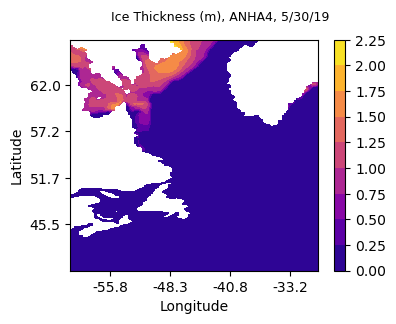

In [8]:
it4 = ds_i4['iicethic'][0, :,:]
it4 = np.where(mask_land4 > 0, it4, np.nan)

fig, ax = plt.subplots(figsize=(4, 3))

#plt.contour(bathy4['Bathymetry'][250:450,125:250], np.array([0, 100, 300, 1000, 3000, 5000]), colors = ['k']*len(bathy_levels), alpha = [1] + [.3]*(len(bathy_levels) -1), linewidths = .75)
lab5 = ax.contourf(it4[250:450, 125:250], np.arange(0, 2.5, .25), cmap='plasma')

ax.set_yticks(np.array([40, 80, 120, 160]), np.trunc(10*ds_t4.nav_lat_grid_T.values[[290, 330, 370, 410], 150])/10)
ax.set_xticks(np.array([20, 50, 80, 110]), np.trunc(10* ds_t4.nav_lon_grid_T.values[250, [170, 200, 230, 260]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(lab5)
fig.suptitle("Ice Thickness (m), ANHA4, 5/30/19", fontsize=9)

Figure for ANHA12

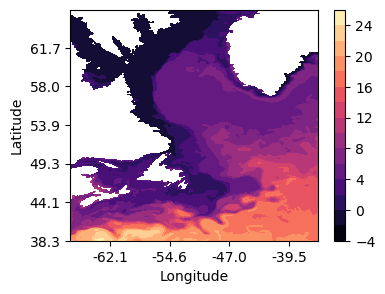

In [9]:
t12 = ds_t12['votemper'][0, 0, :,:]
fig, ax = plt.subplots(figsize=(4, 3))

lab6 = ax.contourf(t12[750:1350, 375:750], np.arange(-4, 28, 2), cmap='magma')
ax.set_yticks(np.array([0, 100, 200, 300, 400, 500]), np.trunc(10*ds_t12.nav_lat.values[[750, 850, 950, 1050, 1150, 1250], 375])/10)
ax.set_xticks(np.array([60, 150, 240, 330]), np.trunc(10* ds_t12.nav_lon.values[750, [435, 525, 615, 705]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")
fig.colorbar(lab6)


Text(0.5, 0.98, 'Practical Salinity (0m), ANHA12, 5/30/19')

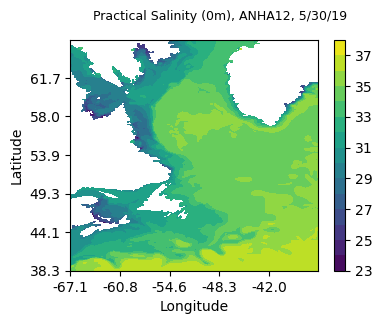

In [10]:
s12 = ds_t12['vosaline'][0, 0, :,:]

fig, ax = plt.subplots(figsize=(4, 3))

lab7 = ax.contourf(s12[750:1350, 375:750], np.arange(23,39,1), cmap='viridis')

ax.set_yticks(np.array([0, 100, 200, 300, 400, 500]), np.trunc(10*ds_t12.nav_lat.values[[750, 850, 950, 1050, 1150, 1250], 375])/10)
ax.set_xticks(np.array([0, 75, 150, 225, 300]), np.trunc(10* ds_t12.nav_lon.values[750, [375, 450, 525, 600, 675]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


fig.colorbar(lab7)
fig.suptitle("Practical Salinity (0m), ANHA12, 5/30/19", fontsize=9)

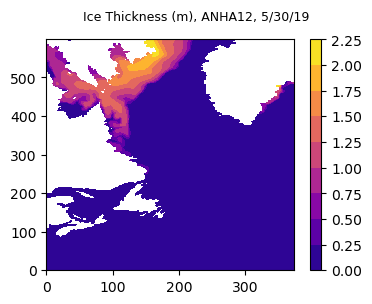

In [11]:
it12 = ds_i12['iicethic'][0, :,:][750:1350, 375:750]

fig, ax = plt.subplots(figsize=(4, 3))


m = ~np.isnan(ds_i12['iicethic'][0, :,:][750:1350, 375:750])

b = ~np.isnan(s12[750:1350, 375:750])

mask_noice = np.ma.make_mask(m != b)

it12 = np.where(mask_noice == 0, it12, 0)

lab8 = ax.contourf(it12, np.arange(0, 2.5, .25), cmap = 'plasma')

fig.suptitle("Ice Thickness (m), ANHA12, 5/30/19", fontsize=9)

fig.colorbar(lab8)

Text(0.5, 0.98, 'Ice Concentration (%), ANHA12, 5/30/19')

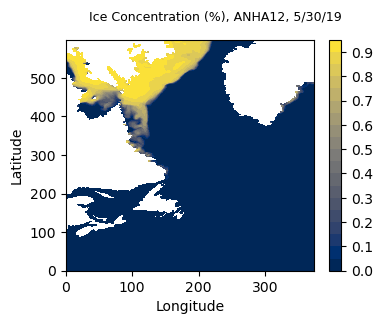

In [12]:
ic12 = ds_i12['ileadfra'][0, :,:][750:1350, 375:750]

fig, ax = plt.subplots(figsize=(4, 3))

m = ~np.isnan(ds_i12['iicethic'][0, :,:][750:1350, 375:750])

b = ~np.isnan(s12[750:1350, 375:750])

mask_noice = np.ma.make_mask(m != b)

ic12 = np.where(mask_noice == 0, ic12, 0)

lab9 = ax.contourf(ic12, np.arange(0,1,.05), cmap='cividis')

ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")

fig.colorbar(lab9)
fig.suptitle("Ice Concentration (%), ANHA12, 5/30/19", fontsize=9)

Text(0.5, 0.98, 'Top 50m Average Velocity, ANHA12, 5/30/19')

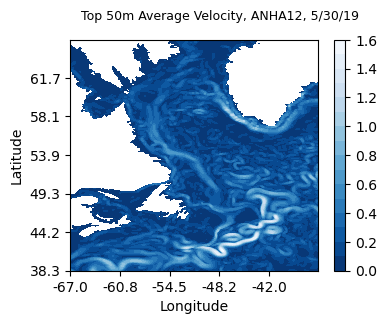

In [13]:
u12 = ds_u12['vozocrtx'][0, :19, 750:1350, 375:750].mean('depthu').compute()

#u12 = np.where(u12 != 0, u12, np.nan)

v12 = ds_v12['vomecrty'][0, :19, 750:1350, 375:750].mean('depthv').compute()
#v12 = np.where(v12 != 0, v12, np.nan)

fig, ax = plt.subplots(figsize=(4, 3))

#plt.contour(bathy12['Bathymetry'][250:450,125:250], np.array([0, 100, 300, 1000, 3000, 5000]), colors = ['k']*len(bathy_levels), alpha = [1] + [.3]*(len(bathy_levels) -1), linewidths = .75)
lab10 = ax.contourf(np.sqrt(v12**2 + u12**2), np.arange(0, 1.7, .1), cmap='Blues_r')

ax.set_yticks(np.array([0, 100, 200, 300, 400, 500]), np.trunc(10*ds_u12.nav_lat.values[[750, 850, 950, 1050, 1150, 1250], 375])/10)
ax.set_xticks(np.array([0, 75, 150, 225, 300]), np.trunc(10* ds_u12.nav_lon.values[750, [375, 450, 525, 600, 675]])/10)
ax.set_xlabel("Longitude")
ax.set_ylabel("Latitude")


fig.colorbar(lab10)
fig.suptitle("Top 50m Average Velocity, ANHA12, 5/30/19", fontsize=9)

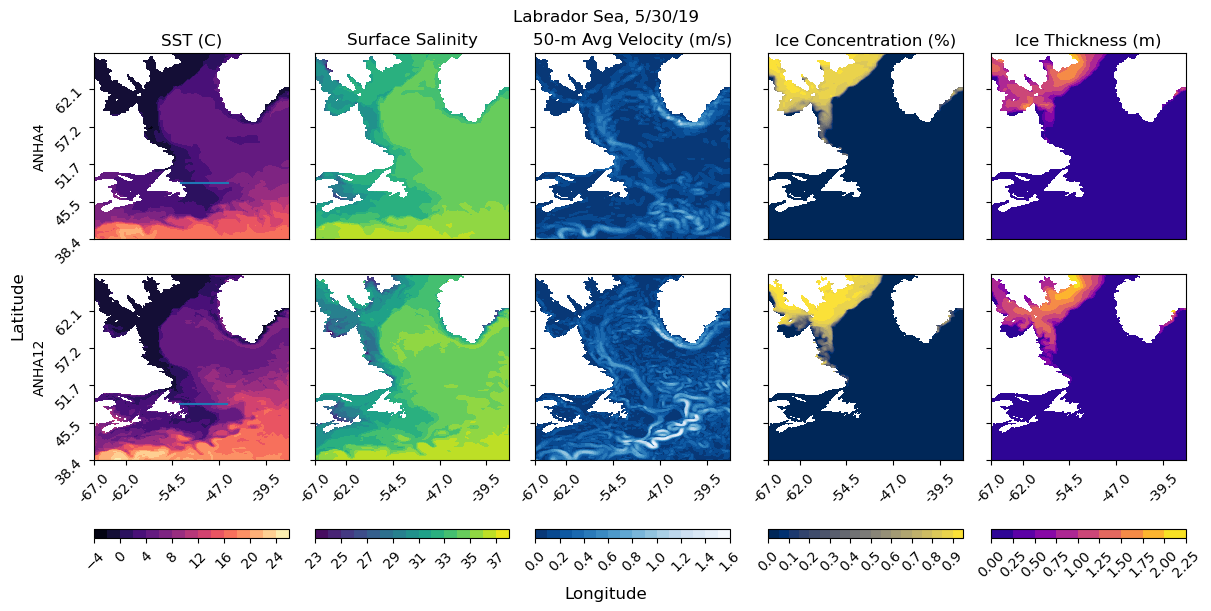

In [46]:
fig, axes = plt.subplots(2,5, figsize=(12,6),layout='constrained', sharey='row')

lab1 = axes[0,0].contourf(t4[250:450, 125:250], np.arange(-4,28,2), cmap='magma')
axes[0,0].plot([55, 85], [85-25, 85-25])
lab2 = axes[0,1].contourf(s4[250:450, 125:250], np.arange(23,39,1), cmap='viridis')
lab3 = axes[0,2].contourf(np.sqrt(u4**2 + v4**2), np.arange(0, 1.7, .1), cmap='Blues_r')
lab4 = axes[0,3].contourf(ic4[250:450, 125:250], np.arange(0,1,.05), cmap='cividis')
lab5 = axes[0,4].contourf(it4[250:450, 125:250], np.arange(0, 2.5, .25), cmap='plasma')
lab6 = axes[1,0].contourf(t12[750:1350, 375:750], np.arange(-4, 28, 2), cmap='magma')
axes[1,0].plot([55*3, 85*3], [(85-25)*3, (85-25)*3])
lab7 = axes[1,1].contourf(s12[750:1350, 375:750], np.arange(23,39,1), cmap='viridis')
lab8 = axes[1,2].contourf(np.sqrt(v12**2 + u12**2), np.arange(0, 1.7, .1), cmap='Blues_r')
lab9 = axes[1,3].contourf(ic12, np.arange(0,1,.05), cmap='cividis')
lab10 = axes[1,4].contourf(it12, np.arange(0, 2.5, .25), cmap = 'plasma')

for x in range(5):
    axes[1,x].set_xticks(np.array([0, 60, 150, 240, 330]), np.trunc(10*ds_u12.nav_lon.values[750, [375, 435, 525, 615, 705]])/10)
    axes[1,x].tick_params(rotation=45)
    axes[0,x].set_xticks([])


axes[0,0].set_yticks(np.array([0, 40, 80, 120, 160]), np.trunc(10* ds_u4.nav_lat.values[[250,290, 330, 370, 410], 150])/10)   
axes[1,0].set_yticks(np.array([0, 120, 240, 360, 480]), np.trunc(10* ds_u12.nav_lat.values[[750, 870, 990, 1110, 1230], 450])/10)
axes[0,0].tick_params(rotation=45)

fig.suptitle("Labrador Sea, 5/30/19")

axes[0,0].set_title("SST (C)")
axes[0,1].set_title("Surface Salinity")
axes[0,2].set_title("50-m Avg Velocity (m/s)")
axes[0,3].set_title("Ice Concentration (%)")
axes[0,4].set_title("Ice Thickness (m)")

fig.supxlabel("Longitude")

axes[0,0].set_ylabel("ANHA4")
axes[1,0].set_ylabel("ANHA12")
fig.supylabel("Latitude")

a = fig.colorbar(lab1, ax=axes[:, 0], location = 'bottom')
b = fig.colorbar(lab2, ax=axes[:, 1], location = 'bottom')
c = fig.colorbar(lab3, ax=axes[:, 2], location = 'bottom')
d = fig.colorbar(lab4, ax=axes[:, 3], location = 'bottom')
e = fig.colorbar(lab5, ax=axes[:, 4], location = 'bottom')


a.ax.tick_params(rotation=45)
b.ax.tick_params(rotation=45)
c.ax.tick_params(rotation=45)
d.ax.tick_params(rotation=45)
e.ax.tick_params(rotation=45)


